In [3]:
%pip install pandas geopandas matplotlib

  Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached geopandas-1.1.4-py3-none-any.whl.metadata (2.3 kB)
  Using cached pyogrio-0.13.0-cp311-abi3-win_amd64.whl.metadata (6.0 kB)
  Using cached shapely-2.1.2-cp313-cp313-win_amd64.whl.metadata (7.1 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl (9.8 MB)
Using cached geopandas-1.1.4-py3-none-any.whl (343 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 3.5 MB/s eta 0:00:03
   ------ ------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
# Configurar el entorno

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
print ("Entorno configurado correctamente")


Entorno configurado correctamente


In [5]:
# 1. CARGAR LOS DATOS DE LOS CENTROS SANITARIOS
csv_file = "../Data/centros_salud_madrid.csv"

df = pd.read_csv(
    csv_file,
    sep=";",
    encoding="cp1252"
)

print("Archivo cargado correctamente")
print("Número de centros:", len(df))

Archivo cargado correctamente
Número de centros: 277


In [6]:
# Comprobar las coordenadas 

print(df[["NOMBRE", "LATITUD", "LONGITUD"]].head())

                                              NOMBRE    LATITUD  LONGITUD
0  Centro Concertado de adicciones (CCAD) Centro ...  40.427474 -3.697485
1  Centro Concertado de Atención a las Adicciones...  40.446053 -3.670277
2  Centro Concertado de Atención a las Adicciones...  40.416331 -3.723991
3  Centro de Atención a las Adicciones (CAD) de A...  40.393057 -3.698067
4  Centro de Atención a las Adicciones (CAD) de H...  40.468289 -3.636150


In [7]:
# 2. CREAR EL GEODATAFRAME A PARTIR DEL DATAFRAME ORIGINAL

geometry = gpd.points_from_xy(
    df["LONGITUD"],
    df["LATITUD"]
)

gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs="EPSG:4326"
)

print("GeoDataFrame creado correctamente")
print("Número de centros:", len(gdf))

display(
    gdf[["NOMBRE", "LATITUD", "LONGITUD", "geometry"]].head()
)

GeoDataFrame creado correctamente
Número de centros: 277


,NOMBRE,LATITUD,LONGITUD,geometry
0,Centro Concertado de adicciones (CCAD) Centro ...,40.427474,-3.697485,POINT (-3.69749 40.42747)
1,Centro Concertado de Atención a las Adicciones...,40.446053,-3.670277,POINT (-3.67028 40.44605)
2,Centro Concertado de Atención a las Adicciones...,40.416331,-3.723991,POINT (-3.72399 40.41633)
3,Centro de Atención a las Adicciones (CAD) de A...,40.393057,-3.698067,POINT (-3.69807 40.39306)
4,Centro de Atención a las Adicciones (CAD) de H...,40.468289,-3.636150,POINT (-3.63615 40.46829)


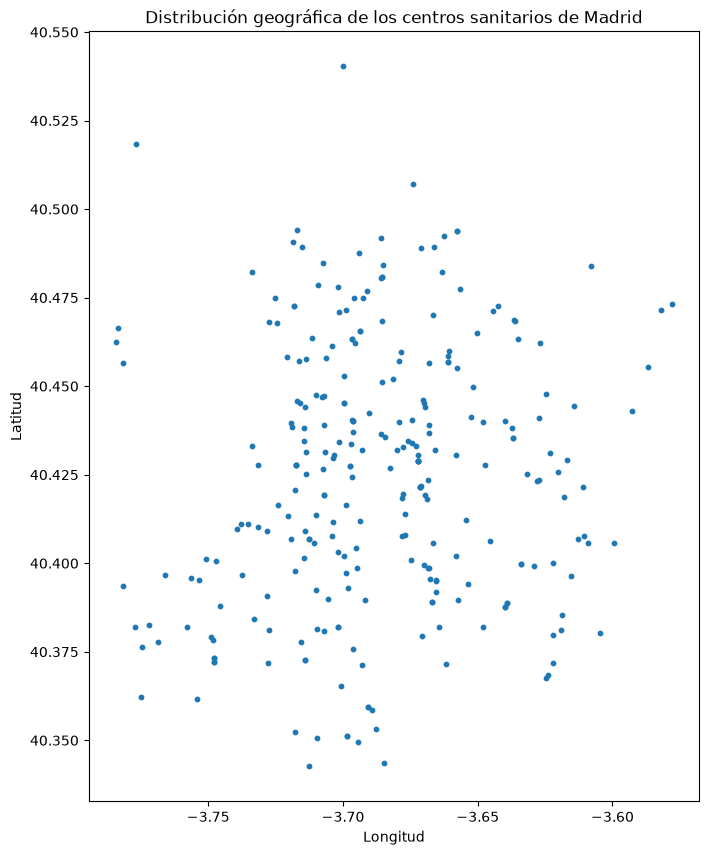

In [8]:
# Representar la ubicación de los centros de salud en un mapa

gdf.plot(
    figsize=(10, 10),
    markersize=10
)

plt.title("Distribución geográfica de los centros sanitarios de Madrid")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

In [9]:
# 3. CARGAR LOS DATOS DE DISTRITOS DE MADRID 

distritos = gpd.read_file(
    "../Data/Distritos/DISTRITOS.shp"
)

print("Distritos cargados correctamente")
print("Número de distritos:", len(distritos))

Distritos cargados correctamente
Número de distritos: 21


In [10]:
print("Columnas de los distritos:")
print(distritos.columns.tolist())

print("\nCRS de los distritos:")
print(distritos.crs)

print("\nCRS de los centros:")
print(gdf.crs)

display(distritos.head())

Columnas de los distritos:
['COD_DIS', 'COD_DIS_TX', 'NOMBRE', 'DISTRI_MAY', 'DISTRI_MT', 'Area', 'geometry']

CRS de los distritos:
EPSG:25830

CRS de los centros:
EPSG:4326


,COD_DIS,COD_DIS_TX,NOMBRE,DISTRI_MAY,DISTRI_MT,Area,geometry
0,1,01,Centro,CENTRO,CENTRO,5.228246e+06,"POLYGON ((441184.784 4473200.78, 441181.244 44..."
1,2,02,Arganzuela,ARGANZUELA,ARGANZUELA,6.462176e+06,"POLYGON ((440272.919 4472969.567, 440350.318 4..."
2,3,03,Retiro,RETIRO,RETIRO,5.466211e+06,"POLYGON ((443652.149 4473312.6, 443560.739 447..."
3,4,04,Salamanca,SALAMANCA,SALAMANCA,5.392404e+06,"POLYGON ((444075.178 4476611.827, 444057.808 4..."
4,5,05,Chamartín,CHAMARTIN,CHAMARTÍN,9.175482e+06,"POLYGON ((442904.114 4481525.212, 442901.02 44..."


In [11]:
# Modificar los distritos al sistema de coordenadas de los centros de salud

distritos = distritos.to_crs(gdf.crs)

print("CRS de los distritos:", distritos.crs)
print("CRS de los centros:", gdf.crs)

CRS de los distritos: EPSG:4326
CRS de los centros: EPSG:4326


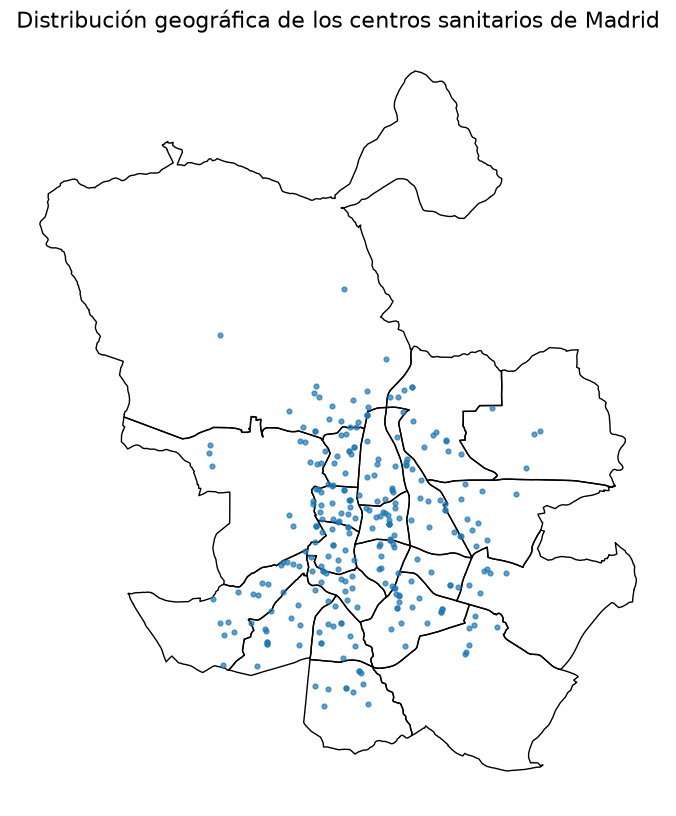

In [12]:
# Crear el espacio de dibujo 
fig, ax = plt.subplots(figsize=(10, 10))

# Dibujar los límites de los distritos
distritos.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

# Dibujar los centros sanitarios
gdf.plot(
    ax=ax,
    markersize=12,
    alpha=0.7
)

ax.set_title(
    "Distribución geográfica de los centros sanitarios de Madrid",
    fontsize=16
)

ax.set_axis_off()

plt.show()

In [13]:
# 4. RELACIONAR CADA CENTRO SANITARIO CON EL DISTRITO DONDE SE ENCUENTRA (SPATIAL JOIN)
centros_distrito = gpd.sjoin(
    gdf,
    distritos,
    how="left",
    predicate="within"
)

# Comprobar el resultado del Spatial Join
print("Número de centros:", len(centros_distrito))

print("\nColumnas resultantes:")
print(centros_distrito.columns.tolist())

display(centros_distrito.head())


Número de centros: 277

Columnas resultantes:
['PK', 'NOMBRE_left', 'DESCRIPCION-ENTIDAD', 'HORARIO', 'EQUIPAMIENTO', 'TRANSPORTE', 'DESCRIPCION', 'ACCESIBILIDAD', 'CONTENT-URL', 'NOMBRE-VIA', 'CLASE-VIAL', 'TIPO-NUM', 'NUM', 'PLANTA', 'PUERTA', 'ESCALERAS', 'ORIENTACION', 'LOCALIDAD', 'PROVINCIA', 'CODIGO-POSTAL', 'COD-BARRIO', 'BARRIO', 'COD-DISTRITO', 'DISTRITO', 'COORDENADA-X', 'COORDENADA-Y', 'LATITUD', 'LONGITUD', 'TELEFONO', 'FAX', 'EMAIL', 'TIPO', 'geometry', 'index_right', 'COD_DIS', 'COD_DIS_TX', 'NOMBRE_right', 'DISTRI_MAY', 'DISTRI_MT', 'Area']


,PK,NOMBRE_left,DESCRIPCION-ENTIDAD,HORARIO,EQUIPAMIENTO,TRANSPORTE,DESCRIPCION,ACCESIBILIDAD,CONTENT-URL,NOMBRE-VIA,...,EMAIL,TIPO,geometry,index_right,COD_DIS,COD_DIS_TX,NOMBRE_right,DISTRI_MAY,DISTRI_MT,Area
0,5855213,Centro Concertado de adicciones (CCAD) Centro ...,El Centro concertado de adicciones Centro form...,De lunes a viernes de 9 a 17 horas,Valoración interdisciplinar del/de la paciente...,"Metro: Alonso Martínez, L4, L5, L10",Forma de acceso: directo,1,http://www.madrid.es/sites/v/index.jsp?vgnextc...,HERMANOS ALVAREZ QUINTERO,...,ctdcentro@cruzroja.es,/contenido/entidadesYorganismos/CentrosAtencio...,POINT (-3.69749 40.42747),0,1,01,Centro,CENTRO,CENTRO,5.228246e+06
1,134929,Centro Concertado de Atención a las Adicciones...,El CCAD Cáritas que forma parte de la red del ...,"De lunes a viernes mañanas de 9 a 14 horas, ta...",Valoración interdisciplinar del/de la paciente...,"Bus: 9, 73, N2Metro: Alfonso XIII (L4), Prospe...",NaN,1,http://www.madrid.es/sites/v/index.jsp?vgnextc...,SANTA HORTENSIA,...,tto.adicciones@caritasmadrid.org,/contenido/entidadesYorganismos/CentrosAtencio...,POINT (-3.67028 40.44605),4,5,05,Chamartín,CHAMARTIN,CHAMARTÍN,9.175482e+06
2,53123,Centro Concertado de Atención a las Adicciones...,El CCAD Casa de Campo que forma parte de la r...,De lunes a viernes de 9 a 17 horas,Valoración interdisciplinar del paciente. Trat...,"Bus: 31, 33, 36, 39, 65, 138 Metro:Puerta del ...",Forma de acceso: directo,1,http://www.madrid.es/sites/v/index.jsp?vgnextc...,PORTUGAL,...,ctdccampo@cruzroja.es,/contenido/entidadesYorganismos/CentrosAtencio...,POINT (-3.72399 40.41633),9,10,10,Latina,LATINA,LATINA,2.541039e+07
3,11867,Centro de Atención a las Adicciones (CAD) de A...,Se trata de un centro público que proporciona ...,Horario ordinario: De septiembre a junio: ...,Valoración interdisciplinar de cada usuario. ...,"Bus: 6 , 8 , 18 , 19 , 22 , 45 , 47 , 76 , 78 ...","Forma de acceso: directo, a través de los serv...",1,http://www.madrid.es/sites/v/index.jsp?vgnextc...,CHOPERA,...,cadarganzuela@madrid.es,/contenido/entidadesYorganismos/CentrosAtencio...,POINT (-3.69807 40.39306),1,2,02,Arganzuela,ARGANZUELA,ARGANZUELA,6.462176e+06
4,11887,Centro de Atención a las Adicciones (CAD) de H...,Se trata de un centro público que proporciona ...,Horario ordinario: De septiembre a junio: ...,Valoración interdisciplinar de cada usuario. ...,"Bus: 73, 87, 104, 112, 120, 125, 153, 172Metro...","Acceso: directo, a través de los servicios mun...",1,http://www.madrid.es/sites/v/index.jsp?vgnextc...,MINAYA,...,cadhortaleza@madrid. es,/contenido/entidadesYorganismos/CentrosAtencio...,POINT (-3.63615 40.46829),15,16,16,Hortaleza,HORTALEZA,HORTALEZA,2.762398e+07


In [14]:
# 5. NÚMERO DE CENTROS SANITARIOS POR DISTRITO
centros_por_distrito = (
    centros_distrito["NOMBRE_right"]
    .value_counts()
    .rename_axis("NOMBRE")
    .reset_index(name="NUM_CENTROS")
)

print("Centros sanitarios por distrito:")
display(centros_por_distrito)

Centros sanitarios por distrito:


,NOMBRE,NUM_CENTROS
0,Fuencarral - El Pardo,22
1,Salamanca,21
2,Latina,20
3,Chamberí,20
4,Puente de Vallecas,19
5,Moncloa - Aravaca,19
6,Ciudad Lineal,18
7,Arganzuela,13
8,Hortaleza,13
9,Carabanchel,13


In [15]:
# Añadir el número de centros a los polígonos de los distritos (MERGE)
distritos_mapa = distritos.merge(
    centros_por_distrito,
    on="NOMBRE",
    how="left"
)

# Los distritos sin centros tendrán valor 0
distritos_mapa["NUM_CENTROS"] = (
    distritos_mapa["NUM_CENTROS"]
    .fillna(0)
)

print("Datos preparados para el mapa:")
display(distritos_mapa[["NOMBRE", "NUM_CENTROS", "geometry"]])

Datos preparados para el mapa:


,NOMBRE,NUM_CENTROS,geometry
0,Centro,12,"POLYGON ((-3.69316 40.40735, -3.6932 40.4072, ..."
1,Arganzuela,13,"POLYGON ((-3.70389 40.4052, -3.70297 40.40506,..."
2,Retiro,10,"POLYGON ((-3.66409 40.40852, -3.66515 40.40646..."
3,Salamanca,21,"POLYGON ((-3.6594 40.43827, -3.65959 40.43698,..."
4,Chamartín,12,"POLYGON ((-3.67365 40.48246, -3.67368 40.48219..."
5,Tetuán,11,"POLYGON ((-3.69764 40.47454, -3.6975 40.47454,..."
6,Chamberí,20,"POLYGON ((-3.69126 40.44621, -3.69179 40.44126..."
7,Fuencarral - El Pardo,22,"POLYGON ((-3.65761 40.51172, -3.65761 40.51172..."
8,Moncloa - Aravaca,19,"POLYGON ((-3.7746 40.40031, -3.77437 40.40208,..."
9,Latina,20,"POLYGON ((-3.77162 40.35982, -3.77235 40.35977..."


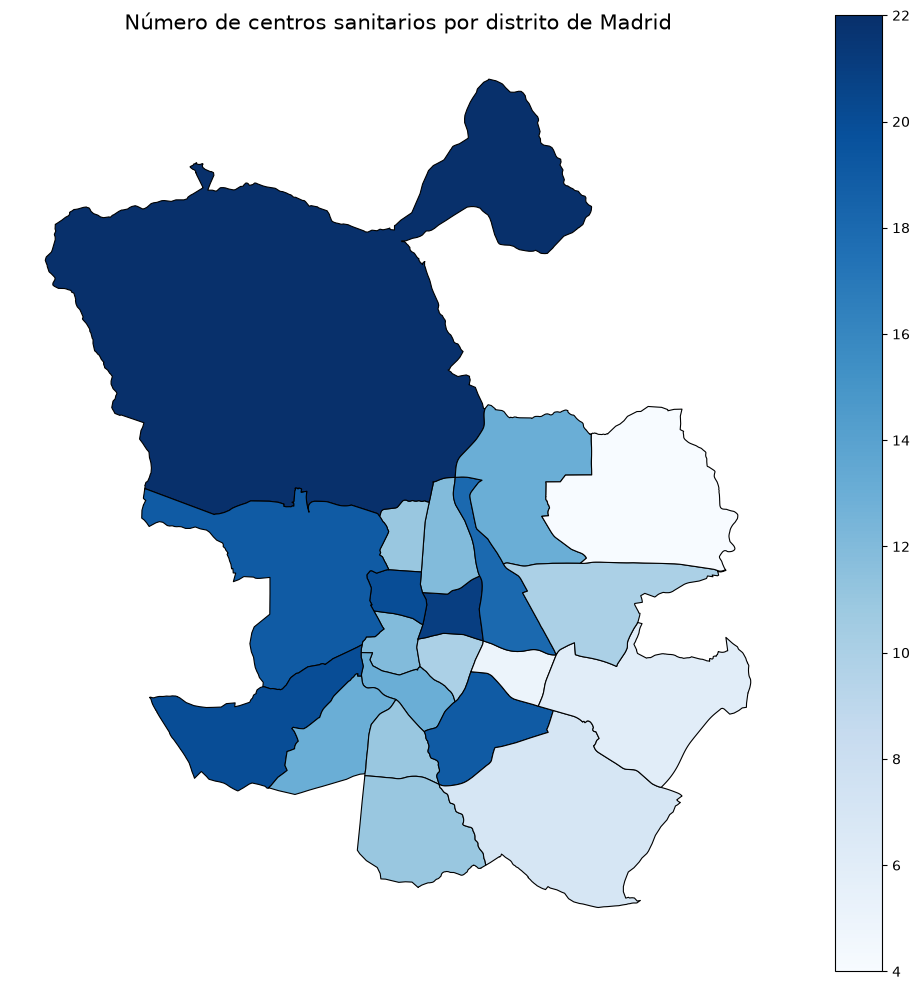

In [16]:
# 6. CREAR MAPA ANALÍTICO

# Crear entorno de dibujo
fig, ax = plt.subplots(figsize=(10, 10))

# Dibujar los distritos con el número de centros sanitarios
distritos_mapa.plot(
    column="NUM_CENTROS",
    cmap="Blues",
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title(
    "Número de centros sanitarios por distrito de Madrid",
    fontsize=15
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [17]:
# 7. CARGAR LOS DATOS DE POBLACIÓN POR DISTRITO

csv_poblacion = "../Data/Poblacion_distritos.csv"

poblacion = pd.read_csv(
    csv_poblacion,
    sep=";",
    encoding="latin-1",
    thousands="."
)

print("Archivo de población cargado correctamente")
print(poblacion.head())

print("Dimensiones:", poblacion.shape)

print("\nColumnas:")
print(poblacion.columns.tolist())

print("\nPrimeras filas:")
display(poblacion.head())

Archivo de población cargado correctamente
             ï»¿fecha  cod_municipio municipio  cod_distrito distrito  \
0  1 de enero de 2026          28079    Madrid             1   Centro   
1  1 de enero de 2026          28079    Madrid             1   Centro   
2  1 de enero de 2026          28079    Madrid             1   Centro   
3  1 de enero de 2026          28079    Madrid             1   Centro   
4  1 de enero de 2026          28079    Madrid             1   Centro   

   cod_barrio       barrio  num_personas  num_personas_hombres  \
0          11      Palacio         23410                 11320   
1          12  Embajadores         48085                 25546   
2          13       Cortes         10740                  5365   
3          14     Justicia         18140                  9112   
4          15  Universidad         33326                 16532   

   num_personas_mujeres  
0                 12090  
1                 22539  
2                  5375  
3                

,ï»¿fecha,cod_municipio,municipio,cod_distrito,distrito,cod_barrio,barrio,num_personas,num_personas_hombres,num_personas_mujeres
0,1 de enero de 2026,28079,Madrid,1,Centro,11,Palacio,23410,11320,12090
1,1 de enero de 2026,28079,Madrid,1,Centro,12,Embajadores,48085,25546,22539
2,1 de enero de 2026,28079,Madrid,1,Centro,13,Cortes,10740,5365,5375
3,1 de enero de 2026,28079,Madrid,1,Centro,14,Justicia,18140,9112,9028
4,1 de enero de 2026,28079,Madrid,1,Centro,15,Universidad,33326,16532,16794


In [18]:
# Eliminar registros repetidos del mismo barrio
poblacion_unica = (
    poblacion
    .drop_duplicates(subset=["distrito", "barrio"])
)

print("Filas originales:", len(poblacion))
print("Filas después de eliminar duplicados:", len(poblacion_unica))

display(
    poblacion_unica[["distrito", "barrio", "num_personas"]].head(20)
)


# Calcular población total por distrito
poblacion_distrito = (
    poblacion_unica
    .groupby("distrito", as_index=False)["num_personas"]
    .sum()
)

poblacion_distrito.columns = ["NOMBRE", "POBLACION"]

display(poblacion_distrito)

Filas originales: 1179
Filas después de eliminar duplicados: 132


,distrito,barrio,num_personas
0,Centro,Palacio,23410
1,Centro,Embajadores,48085
2,Centro,Cortes,10740
3,Centro,Justicia,18140
4,Centro,Universidad,33326
5,Centro,Sol,8099
6,Arganzuela,Imperial,24313
7,Arganzuela,Acacias,36069
8,Arganzuela,Chopera,20366
9,Arganzuela,Legazpi,19916


,NOMBRE,POBLACION
0,Arganzuela,158550
1,Barajas,50613
2,Carabanchel,278090
3,Centro,141800
4,ChamartÃ­n,148093
5,ChamberÃ­,141522
6,Ciudad Lineal,230334
7,Fuencarral-El Pardo,256037
8,Hortaleza,209178
9,Latina,269889


In [19]:
# Limpiar los nombres de los distritos 

poblacion_distrito["NOMBRE"] = (
    poblacion_distrito["NOMBRE"]
    .replace({
        "ChamartÃ­n": "Chamartín",
        "ChamberÃ­": "Chamberí",
        "TetuÃ¡n": "Tetuán",
        "VicÃ¡lvaro": "Vicálvaro",
        "Fuencarral-El Pardo": "Fuencarral - El Pardo",
        "Moncloa-Aravaca": "Moncloa - Aravaca",
        "San Blas-Canillejas": "San Blas - Canillejas"
    })
)

display(poblacion_distrito)


# 8. OBTENER LOS CENTROS SANITARIOS POR DISTRITO

centros_por_distrito = (
    centros_distrito["NOMBRE_right"]
    .value_counts()
    .rename_axis("NOMBRE")
    .reset_index(name="NUM_CENTROS")
)

display(centros_por_distrito)



,NOMBRE,POBLACION
0,Arganzuela,158550
1,Barajas,50613
2,Carabanchel,278090
3,Centro,141800
4,ChamartÃ­n,148093
5,ChamberÃ­,141522
6,Ciudad Lineal,230334
7,Fuencarral-El Pardo,256037
8,Hortaleza,209178
9,Latina,269889


,NOMBRE,NUM_CENTROS
0,Fuencarral - El Pardo,22
1,Salamanca,21
2,Latina,20
3,Chamberí,20
4,Puente de Vallecas,19
5,Moncloa - Aravaca,19
6,Ciudad Lineal,18
7,Arganzuela,13
8,Hortaleza,13
9,Carabanchel,13


In [20]:
# Normalizar nombres de distritos en ambas tablas

def normalizar_distrito(columna):
    return (
        columna
        .str.replace("Ã¡", "á", regex=False)
        .str.replace("Ã©", "é", regex=False)
        .str.replace("Ã­", "í", regex=False)
        .str.replace("Ã³", "ó", regex=False)
        .str.replace("Ãº", "ú", regex=False)
        .str.replace("Ã±", "ñ", regex=False)
        .str.replace("-", " - ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

poblacion_distrito["NOMBRE"] = normalizar_distrito(
    poblacion_distrito["NOMBRE"]
)

centros_por_distrito["NOMBRE"] = normalizar_distrito(
    centros_por_distrito["NOMBRE"]
)

# Comprobar los nombres de los distritos en ambas tablas
print("Distritos de población:")
print(poblacion_distrito["NOMBRE"].tolist())

print("\nDistritos de centros:")
print(centros_por_distrito["NOMBRE"].tolist())



Distritos de población:
['Arganzuela', 'Barajas', 'Carabanchel', 'Centro', 'Chamartín', 'Chamberí', 'Ciudad Lineal', 'Fuencarral - El Pardo', 'Hortaleza', 'Latina', 'Moncloa - Aravaca', 'Moratalaz', 'Puente de Vallecas', 'Retiro', 'Salamanca', 'San Blas - Canillejas', 'Tetuán', 'Usera', 'Vicálvaro', 'Villa de Vallecas', 'Villaverde']

Distritos de centros:
['Fuencarral - El Pardo', 'Salamanca', 'Latina', 'Chamberí', 'Puente de Vallecas', 'Moncloa - Aravaca', 'Ciudad Lineal', 'Arganzuela', 'Hortaleza', 'Carabanchel', 'Centro', 'Chamartín', 'Tetuán', 'Villaverde', 'Usera', 'San Blas - Canillejas', 'Retiro', 'Villa de Vallecas', 'Vicálvaro', 'Moratalaz', 'Barajas']


In [21]:
# UNIR LOS DATOS DE POBLACIÓN Y CENTROS SANITARIOS POR DISTRITO (MERGE)
analisis_distrito = centros_por_distrito.merge(
    poblacion_distrito,
    on="NOMBRE",
    how="left"
)

display(analisis_distrito)

,NOMBRE,NUM_CENTROS,POBLACION
0,Fuencarral - El Pardo,22,256037
1,Salamanca,21,147256
2,Latina,20,269889
3,Chamberí,20,141522
4,Puente de Vallecas,19,257924
5,Moncloa - Aravaca,19,126257
6,Ciudad Lineal,18,230334
7,Arganzuela,13,158550
8,Hortaleza,13,209178
9,Carabanchel,13,278090


In [22]:
# 9. CÁLCULO DEL RATIO DE CENTROS POR CADA 10.000 HABITANTES
analisis_distrito["CENTROS_POR_10000"] = (
    analisis_distrito["NUM_CENTROS"]
    / analisis_distrito["POBLACION"]
    * 10000
)

analisis_distrito

# Ordenar los distritos 
analisis_distrito.sort_values(
    "CENTROS_POR_10000",
    ascending=False
)

,NOMBRE,NUM_CENTROS,POBLACION,CENTROS_POR_10000
5,Moncloa - Aravaca,19,126257,1.504867
1,Salamanca,21,147256,1.426088
3,Chamberí,20,141522,1.413208
0,Fuencarral - El Pardo,22,256037,0.859251
10,Centro,12,141800,0.846262
16,Retiro,10,118863,0.841305
7,Arganzuela,13,158550,0.819931
11,Chamartín,12,148093,0.810302
20,Barajas,4,50613,0.790311
6,Ciudad Lineal,18,230334,0.781474


Mapa de cobertura creado correctamente
                   NOMBRE  NUM_CENTROS  POBLACION  CENTROS_POR_10000
0                  Centro           12     141800           0.846262
1              Arganzuela           13     158550           0.819931
2                  Retiro           10     118863           0.841305
3               Salamanca           21     147256           1.426088
4               Chamartín           12     148093           0.810302
5                  Tetuán           11     167776           0.655636
6                Chamberí           20     141522           1.413208
7   Fuencarral - El Pardo           22     256037           0.859251
8       Moncloa - Aravaca           19     126257           1.504867
9                  Latina           20     269889           0.741045
10            Carabanchel           13     278090           0.467475
11                  Usera           11     152937           0.719250
12     Puente de Vallecas           19     257924           0.73

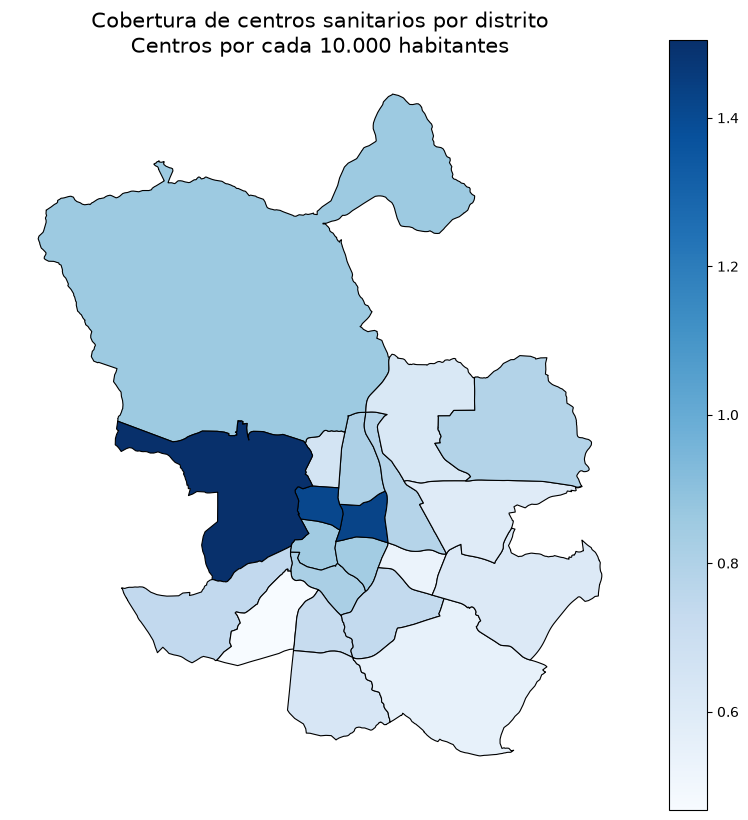

In [23]:
# Unir la información de cobertura con los polígonos de los distritos

mapa_cobertura = distritos.merge(
    analisis_distrito,
    left_on="NOMBRE",
    right_on="NOMBRE",
    how="left"
)

print("Mapa de cobertura creado correctamente")
print(mapa_cobertura[["NOMBRE", "NUM_CENTROS", "POBLACION", "CENTROS_POR_10000"]])

# 10. CREAR MAPA DE COBERTURA DE LOS CENTROS SANITARIOS POR CADA 10.000 HABITANTES

fig, ax = plt.subplots(figsize=(10, 10))

mapa_cobertura.plot(
    column="CENTROS_POR_10000",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.8,
    ax=ax
)

ax.set_title(
    "Cobertura de centros sanitarios por distrito\n"
    "Centros por cada 10.000 habitantes",
    fontsize=15
)

ax.set_axis_off()

plt.show()

In [24]:
# 11. CALCULAR LA COBERTURA MEDIA DE MADRID

media_cobertura = analisis_distrito["CENTROS_POR_10000"].mean()

print(
    f"Cobertura media de Madrid: "
    f"{media_cobertura:.2f} centros por cada 10.000 habitantes"
)

# Comparar cada distrito con la media

analisis_distrito["SITUACION"] = analisis_distrito[
    "CENTROS_POR_10000"
].apply(
    lambda x: "Por encima de la media"
    if x > media_cobertura
    else "Por debajo de la media"
)

display(
    analisis_distrito[
        ["NOMBRE", "NUM_CENTROS", "POBLACION",
         "CENTROS_POR_10000", "SITUACION"]
    ].sort_values(
        "CENTROS_POR_10000",
        ascending=False
    )
)

Cobertura media de Madrid: 0.81 centros por cada 10.000 habitantes


,NOMBRE,NUM_CENTROS,POBLACION,CENTROS_POR_10000,SITUACION
5,Moncloa - Aravaca,19,126257,1.504867,Por encima de la media
1,Salamanca,21,147256,1.426088,Por encima de la media
3,Chamberí,20,141522,1.413208,Por encima de la media
0,Fuencarral - El Pardo,22,256037,0.859251,Por encima de la media
10,Centro,12,141800,0.846262,Por encima de la media
16,Retiro,10,118863,0.841305,Por encima de la media
7,Arganzuela,13,158550,0.819931,Por encima de la media
11,Chamartín,12,148093,0.810302,Por encima de la media
20,Barajas,4,50613,0.790311,Por debajo de la media
6,Ciudad Lineal,18,230334,0.781474,Por debajo de la media


In [25]:
# Distritos por encima de la cobertura media

por_encima = analisis_distrito[
    analisis_distrito["SITUACION"] == "Por encima de la media"
].sort_values(
    "CENTROS_POR_10000",
    ascending=False
)

display(
    por_encima[
        ["NOMBRE", "NUM_CENTROS", "POBLACION", "CENTROS_POR_10000"]
    ]
)

# 3 distritos con mayor y menor cobertura
print("TOP 3 - Mayor cobertura")
display(
    analisis_distrito.nlargest(
        3, "CENTROS_POR_10000"
    )[["NOMBRE", "CENTROS_POR_10000"]]
)

print("TOP 3 - Menor cobertura")
display(
    analisis_distrito.nsmallest(
        3, "CENTROS_POR_10000"
    )[["NOMBRE", "CENTROS_POR_10000"]]
)

,NOMBRE,NUM_CENTROS,POBLACION,CENTROS_POR_10000
5,Moncloa - Aravaca,19,126257,1.504867
1,Salamanca,21,147256,1.426088
3,Chamberí,20,141522,1.413208
0,Fuencarral - El Pardo,22,256037,0.859251
10,Centro,12,141800,0.846262
16,Retiro,10,118863,0.841305
7,Arganzuela,13,158550,0.819931
11,Chamartín,12,148093,0.810302


TOP 3 - Mayor cobertura


,NOMBRE,CENTROS_POR_10000
5,Moncloa - Aravaca,1.504867
1,Salamanca,1.426088
3,Chamberí,1.413208


TOP 3 - Menor cobertura


,NOMBRE,CENTROS_POR_10000
9,Carabanchel,0.467475
19,Moratalaz,0.529633
17,Villa de Vallecas,0.548736


### 12. CONCLUSIONES

<p style="text-align: justify;"> El análisis realizado sobre los centros sanitarios de Madrid
permite ampliar el estudio inicial de la oferta sanitaria,
incorporando una dimensión espacial y poblacional. </p>

<p style="text-align: justify;"> Para ello, se han combinado los datos de los centros sanitarios
con la información geográfica de los distritos y los datos
de población, utilizando diferentes herramientas de análisis
geoespacial en Python. </p>

<p style="text-align: justify;"> En primer lugar, se han utilizado las coordenadas geográficas
de los **277 centros sanitarios** para construir su representación
espacial y poder relacionarlos con la cartografía de los distritos
de Madrid. </p>

<p style="text-align: justify;"> Además, se han trabajado diferentes sistemas de referencia
de coordenadas (CRS) para garantizar que ambas fuentes
de información fueran compatibles. </p>

<p style="text-align: justify;"> Mediante una **unión espacial (Spatial Join)** ha sido posible
determinar el distrito correspondiente a cada centro y analizar
posteriormente su distribución territorial. </p>

<p style="text-align: justify;"> El análisis muestra que el número de centros sanitarios varía
considerablemente entre los distintos distritos. </p>

<p style="text-align: justify;"> **Fuencarral - El Pardo** presenta el mayor número de centros,
con **22**, seguido de **Salamanca**, con **21**, y de
**Latina** y **Chamberí**, con **20 centros** cada uno. </p>

<p style="text-align: justify;"> En el extremo contrario se encuentran **Barajas**, con 4 centros,
**Moratalaz**, con 5, y **Vicálvaro**, con 6. </p>

<p style="text-align: justify;"> Sin embargo, el número absoluto de centros no permite evaluar
por sí solo la disponibilidad relativa de servicios sanitarios. </p>

<p style="text-align: justify;"> Por este motivo, se ha incorporado la población de cada distrito
y se ha calculado un indicador de cobertura basado en el número
de **centros sanitarios por cada 10.000 habitantes**. </p>

<p style="text-align: justify;"> Este indicador pone de manifiesto diferencias importantes
entre distritos. </p>

<p style="text-align: justify;"> **Moncloa - Aravaca** presenta la mayor cobertura relativa,
con **1,50 centros por cada 10.000 habitantes**, seguido de
**Salamanca**, con 1,43, y **Chamberí**, con 1,41. </p>

<p style="text-align: justify;"> Por el contrario, **Carabanchel** presenta el valor más bajo,
con **0,47 centros por cada 10.000 habitantes**, seguido de
**Moratalaz**, con 0,53, y **Villa de Vallecas**, con 0,55. </p>

<p style="text-align: justify;"> Estos resultados muestran que una mayor cantidad de centros
sanitarios no implica necesariamente una mayor cobertura relativa. </p>

<p style="text-align: justify;"> Por ejemplo, **Carabanchel dispone de 13 centros**, pero cuenta
con una población de **278.090 habitantes**. </p>

<p style="text-align: justify;"> En cambio, **Moncloa - Aravaca dispone de 19 centros**
para una población de **126.257 habitantes**. </p>

<p style="text-align: justify;"> La incorporación de la población permite, por tanto, obtener
una visión más equilibrada de las diferencias existentes entre
los distintos territorios. </p>

<p style="text-align: justify;"> La representación cartográfica mediante **GeoPandas** permite
visualizar estas diferencias de forma espacial y facilita
la identificación de posibles desigualdades territoriales
en la distribución relativa de los centros sanitarios. </p>

<p style="text-align: justify;"> No obstante, el indicador utilizado debe interpretarse como
una medida de cobertura basada exclusivamente en la relación
entre centros y población. </p>

<p style="text-align: justify;"> No representa directamente la calidad, capacidad, demanda
o accesibilidad real de los servicios sanitarios. </p>

<p style="text-align: justify;"> En conjunto, esta segunda parte del proyecto demuestra cómo
el análisis de datos puede complementarse con técnicas de
**análisis geoespacial** para obtener conclusiones más completas. </p>

<p style="text-align: justify;"> El uso combinado de **Pandas, GeoPandas, Shapely y Matplotlib**
permite integrar diferentes fuentes de información, realizar
operaciones espaciales, construir indicadores y representar
los resultados mediante mapas. </p>